In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Feature Engineering (example - add more relevant features)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 1
df['IsAlone'].loc[df['FamilySize'] > 1] = 0

# Handle missing values (example - replace with mean/median)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'])

# Define features (X) and target variable (y)
features = ['Age', 'FamilySize', 'IsAlone', 'Fare', 'Sex_female', 'Sex_male',
            'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']
X = df[features]
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train the XGBoost model
model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model (example - accuracy)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8044692737430168


<ipython-input-13-6342deacb8ba>:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['IsAlone'].loc[df['FamilySize'] > 1] = 0
<ipython-input-13-6342deacb8ba>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

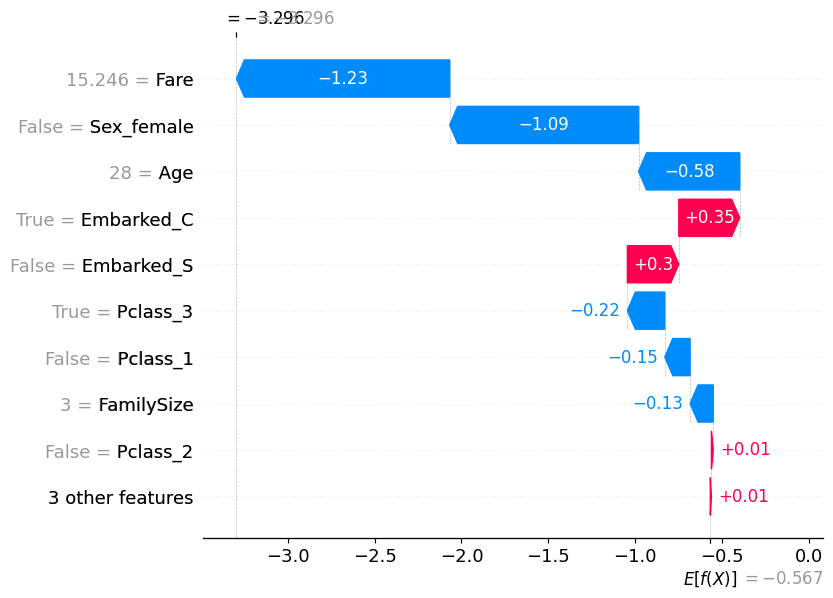

In [14]:
import shap


explainer = shap.Explainer(model)
shap_values = explainer(X_test)


shap.plots.waterfall(shap_values[0])


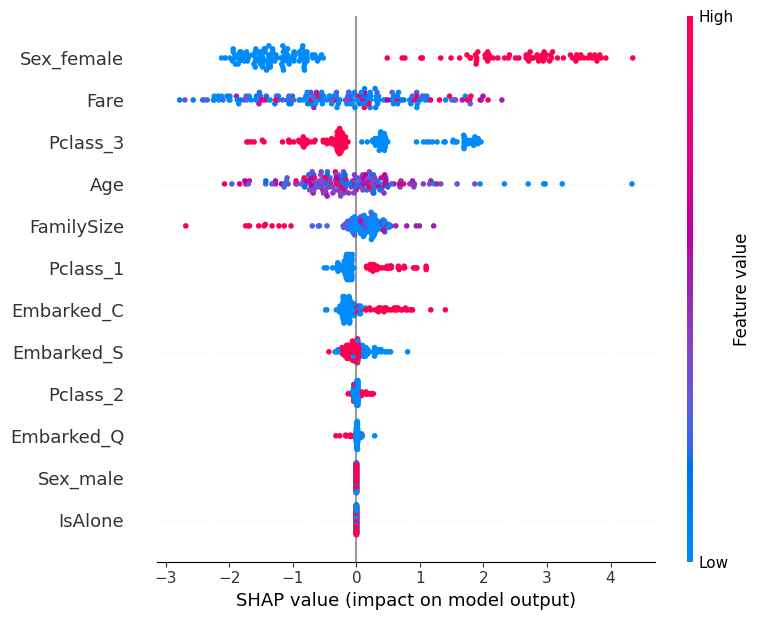

In [15]:
shap.summary_plot(shap_values, X_test)


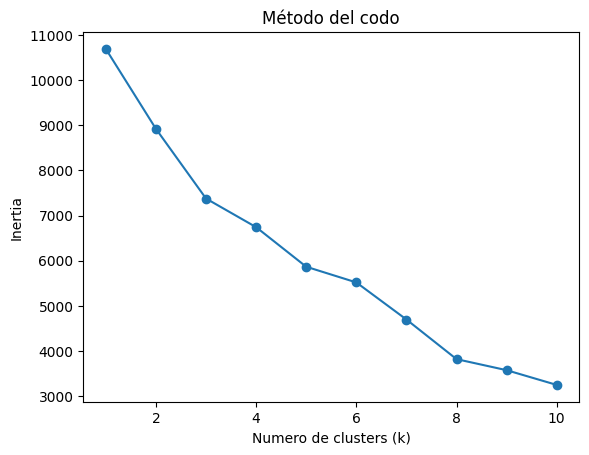

         PassengerId  Survived        Age     SibSp     Parch       Fare  \
Cluster                                                                    
0         453.723077  0.140659  27.766484  0.461538  0.224176  14.342196   
1         414.713636  0.645455  25.345455  0.754545  0.731818  18.140172   
2         461.597222  0.629630  36.812130  0.416667  0.356481  84.154687   

         FamilySize   IsAlone  Sex_female  Sex_male  Embarked_C  Embarked_Q  \
Cluster                                                                       
0          1.685714  0.738462    0.000000  1.000000    0.116484    0.087912   
1          2.486364  0.418182    1.000000  0.000000    0.136364    0.159091   
2          1.773148  0.504630    0.435185  0.564815    0.393519    0.009259   

         Embarked_S  Pclass_1  Pclass_2  Pclass_3  
Cluster                                            
0          0.795604       0.0  0.237363  0.762637  
1          0.704545       0.0  0.345455  0.654545  
2          0.59

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del codo')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inertia')
plt.show()


optimal_k = 3


kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


print(df.groupby('Cluster').mean())


In [18]:
print(df.groupby('Cluster').agg({'Age': 'mean', 'Sex_female': 'mean', 'Fare': 'mean', 'Survived': 'mean'}))


               Age  Sex_female       Fare  Survived
Cluster                                            
0        27.766484    0.000000  14.342196  0.140659
1        25.345455    1.000000  18.140172  0.645455
2        36.812130    0.435185  84.154687  0.629630


3 clusters son los óptimos para la predicción